In [5]:
using LaTeXStrings
using JLD2
using Statistics
using Plots

In [36]:
nAtoms = 1225
Δ = 2000
case = 2
γ_values = [20.0]
Ω_values = round.(vcat(0:2:8, 8.5:0.15:13, 14:0.5:30), digits=2)
#vcat(0:2:16, 17:0.25:32, 33:1:60) #vcat(0:2:10, 10.5:0.025:13, 14:0.5:30) 
#vcat(0:2:24, 25:0.25:32, 33:1:60) #0:2:60 #
script_dir = @__DIR__
Γ = 1
data_dict = Dict()
for γ in γ_values
    γ_str = string(γ)
    data_folder = joinpath(script_dir, "results_data/atoms=$(nAtoms),Δ=$(Δ),γ=$(γ_str)")
    data_dict[γ] = Dict()
    for Ω in Ω_values
        Ω_str = string(Float64(Ω))
        file = joinpath(data_folder, "sz_mean_steady_for_$(case)D,Ω=$(Ω_str),Δ=$(Δ),γ=$(γ_str).jld2")
        try
            data = JLD2.load(file)
            if haskey(data, "Szs")
                Szs = data["Szs"]
                t = data["t"]
                if ndims(Szs) == 2
                    Szs_mean = vec(mean(Szs, dims=2))
                elseif ndims(Szs) == 1
                    Szs_mean = Szs
                else
                    println("Unexpected Szs dimensions in $file: $(size(Szs)). Skipping.")
                    continue
                end
                Szs_mean_transformed = (1 .+ Szs_mean) / 2
                data_dict[γ][Ω] = (t=t, Szs_mean=Szs_mean_transformed)
                println("Loaded file: $file")
            else
                println("Szs key not found in $file. Skipping.")
            end
        catch e
            println("Error loading $file: $e. Skipping.")
        end
    end
end
println("Data loading complete.")

Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=0.0,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=2.0,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=4.0,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=6.0,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=8.0,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=8.5,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/Rydberg_facilitation/results_data/atoms=1225,Δ=2000,γ=20.0/sz_mean_steady_for_2D,Ω=8.65,Δ=2000,γ=20.0.jld2
Loaded file: /Users/hoangnguyen/R

Excluding Ω = 0 from log scale plot for γ = 20.0


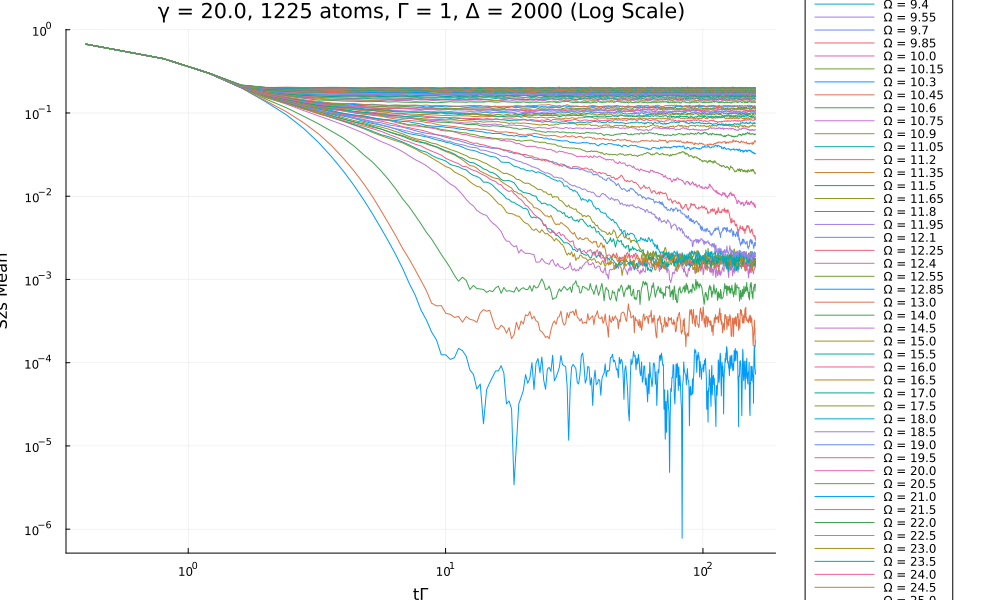

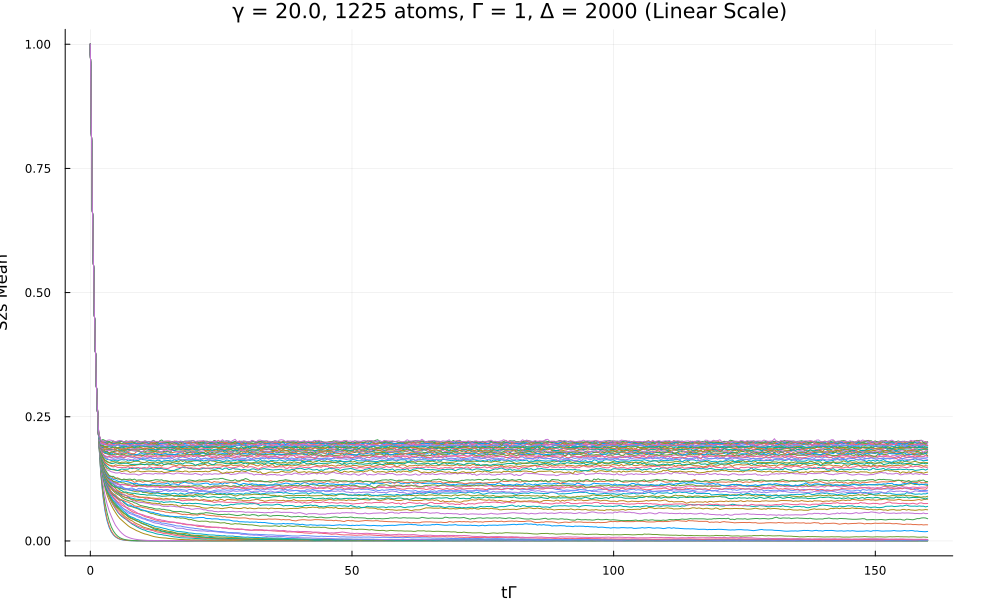

In [37]:
for γ in γ_values
    plt_log = plot(
        xlabel="tΓ",
        ylabel="Szs Mean",
        title="γ = $γ, $nAtoms atoms, Γ = $Γ, Δ = $Δ (Log Scale)",
        legend=:outerright,
        size=(1000, 600),
        right_margin=10Plots.mm,
        xscale=:log10,
        yscale=:log10,
    )
    plt_linear = plot(
        xlabel="tΓ",
        ylabel="Szs Mean",
        title="γ = $γ, $nAtoms atoms, Γ = $Γ, Δ = $Δ (Linear Scale)",
        legend=:false,
        size=(1000, 600),
        right_margin=10Plots.mm,
    )
    for Ω in Ω_values
        if haskey(data_dict[γ], Ω)
            t, Szs_mean = data_dict[γ][Ω]
            valid_indices = (t .> 0) .& (Szs_mean .> 0)
            t_log = t[valid_indices]
            Szs_mean_log = Szs_mean[valid_indices]
            if Ω != 0 && !isempty(t_log)
                plot!(plt_log, t_log, Szs_mean_log, label="Ω = $Ω")
            elseif Ω == 0
                println("Excluding Ω = 0 from log scale plot for γ = $γ")
            elseif isempty(t_log)
                println("No positive data for γ = $γ, Ω = $Ω in log scale plot")
            end
            plot!(plt_linear, t, Szs_mean, label="Ω = $Ω")
        end
    end
    display(plt_log)
    display(plt_linear)
end

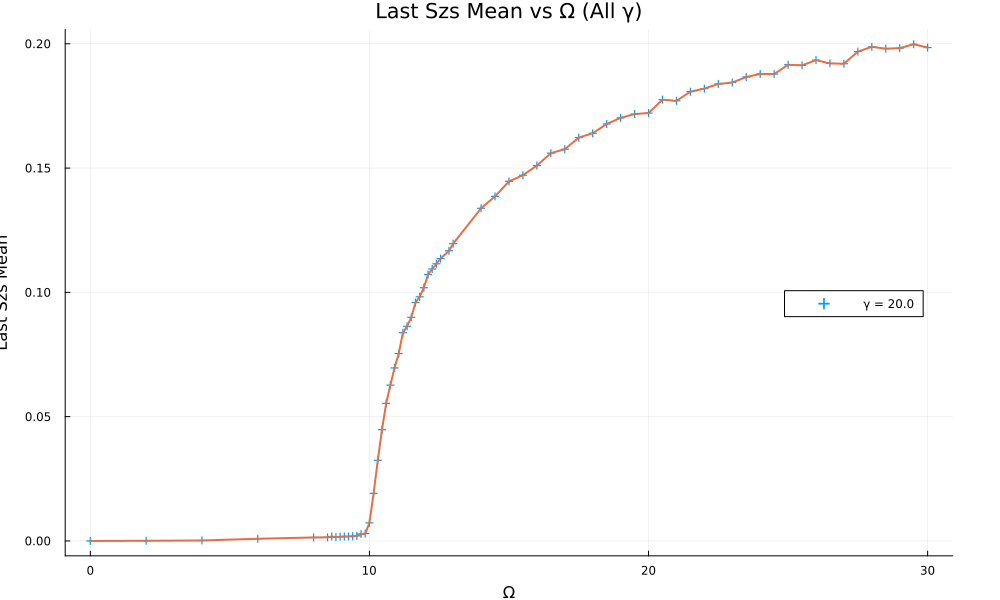

In [41]:
plt2 = plot(
    xlabel="Ω",
    ylabel="Last Szs Mean",
    title="Last Szs Mean vs Ω (All γ)",
    legend=:right,
    size=(1000, 600),
    right_margin=10Plots.mm,
    # xticks=0:1:30
)

for γ in γ_values
    last_Szs_mean_values = Float64[]
    valid_Ω_values = Float64[]
    
    for Ω in Ω_values
        if haskey(data_dict[γ], Ω)
            _, Szs_mean = data_dict[γ][Ω]
            push!(last_Szs_mean_values, Szs_mean[end])
            push!(valid_Ω_values, Ω)
        end
    end
    
    # Scatter plot with markers
    scatter!(plt2, valid_Ω_values, last_Szs_mean_values, label="γ = $γ", marker=:auto)
    
    # Line plot connecting the points
    plot!(plt2, valid_Ω_values, last_Szs_mean_values, seriestype=:line, label="", lw=2)
    
    # Add text annotations for Ω values next to each scatter point
    # for (i, Ω) in enumerate(valid_Ω_values)
    #     annotate!(plt2, valid_Ω_values[i], last_Szs_mean_values[i], text("$(round(Ω, digits=2))", :top, 5, color=:black))
    # end
end

display(plt2)

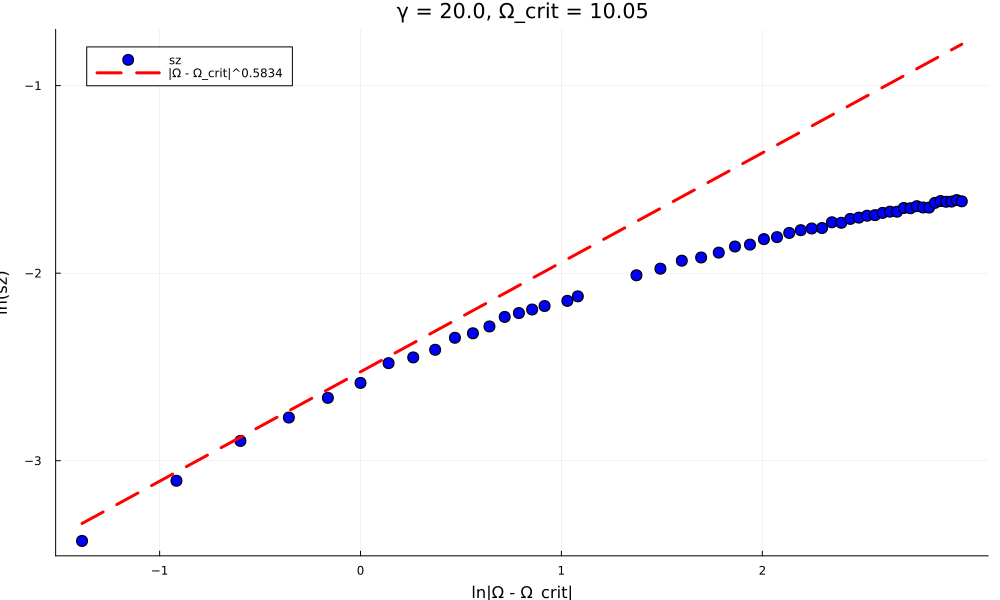

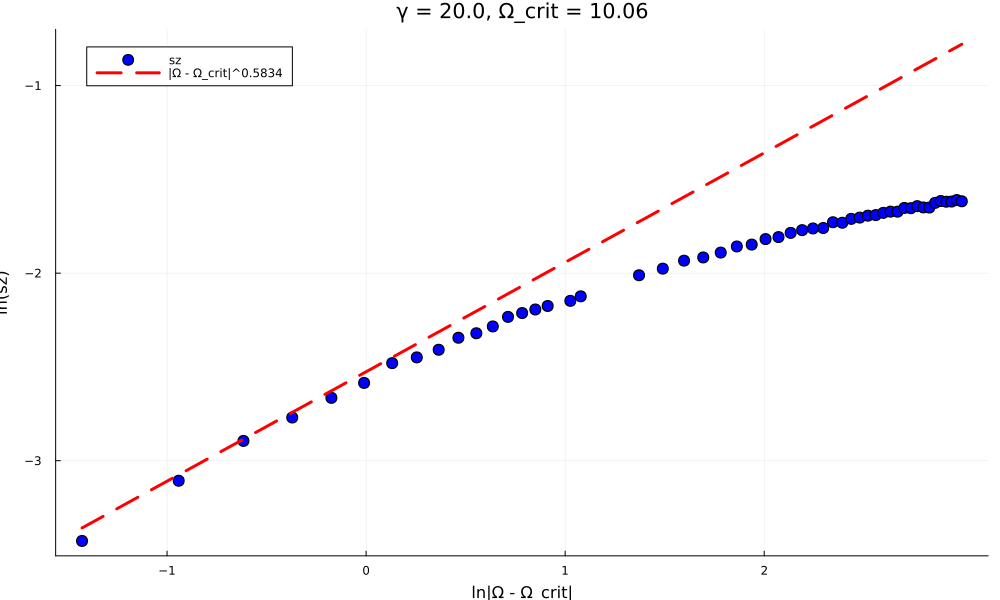

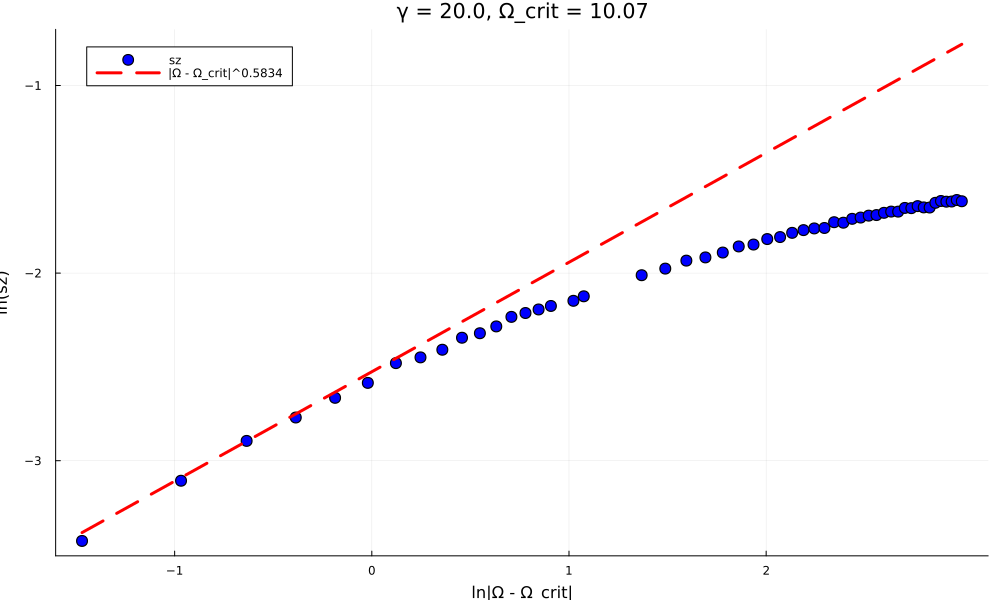

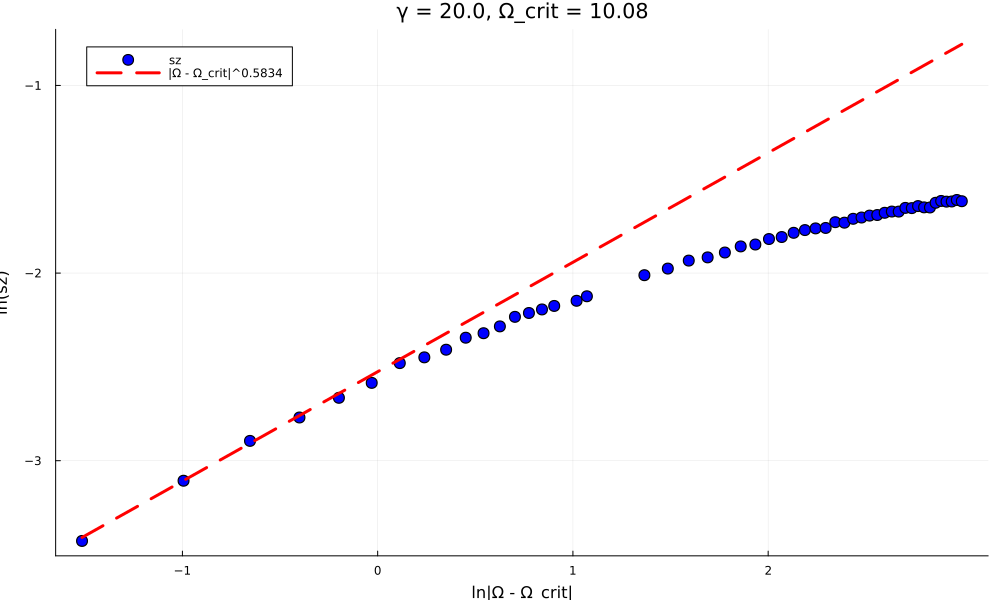

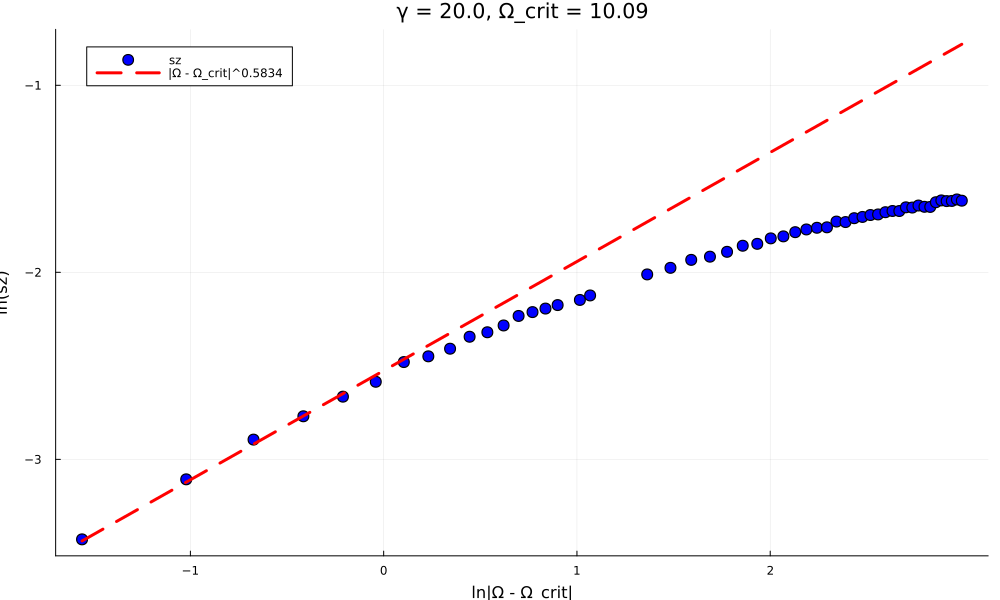

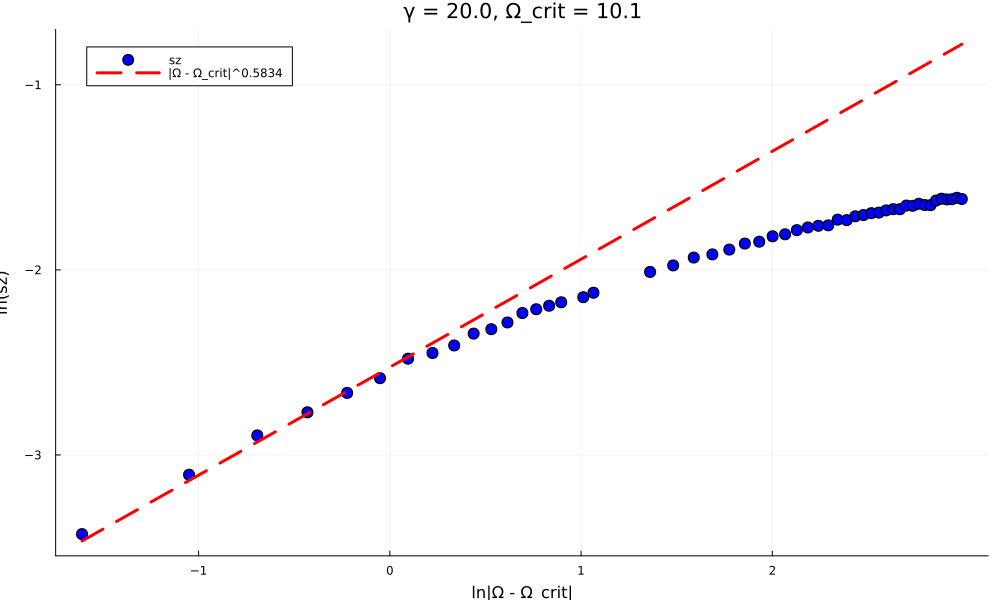

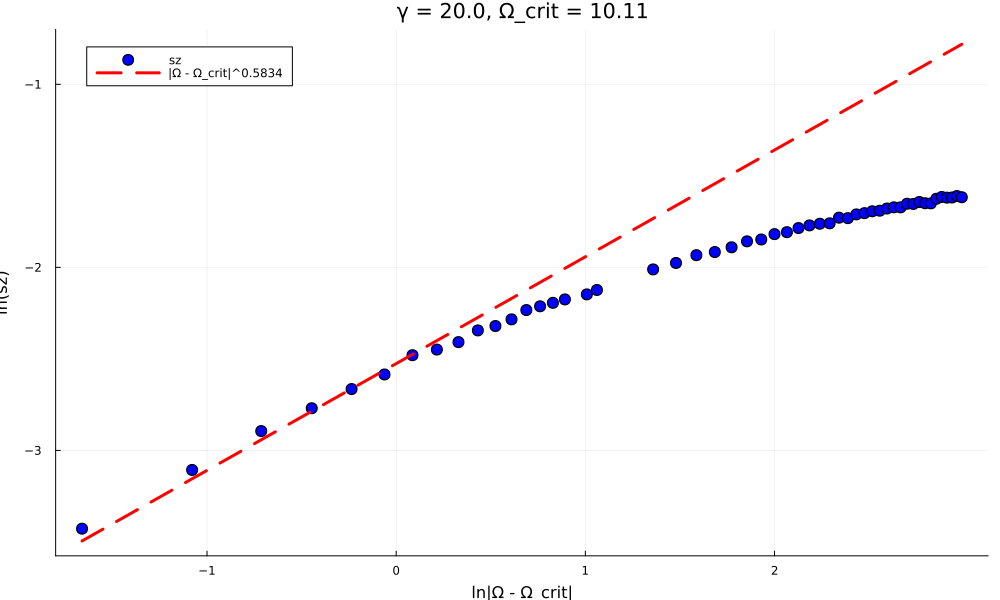

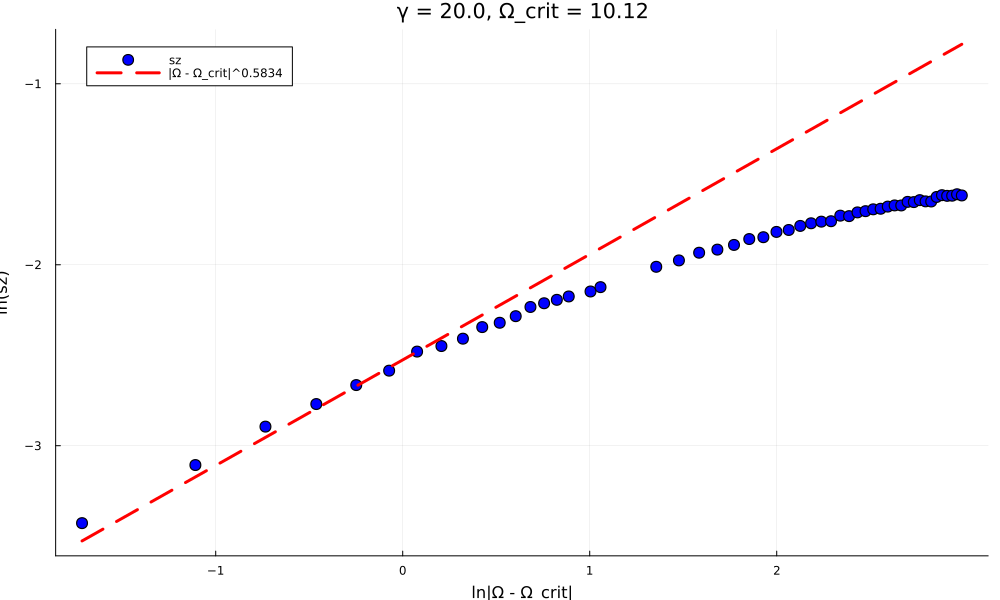

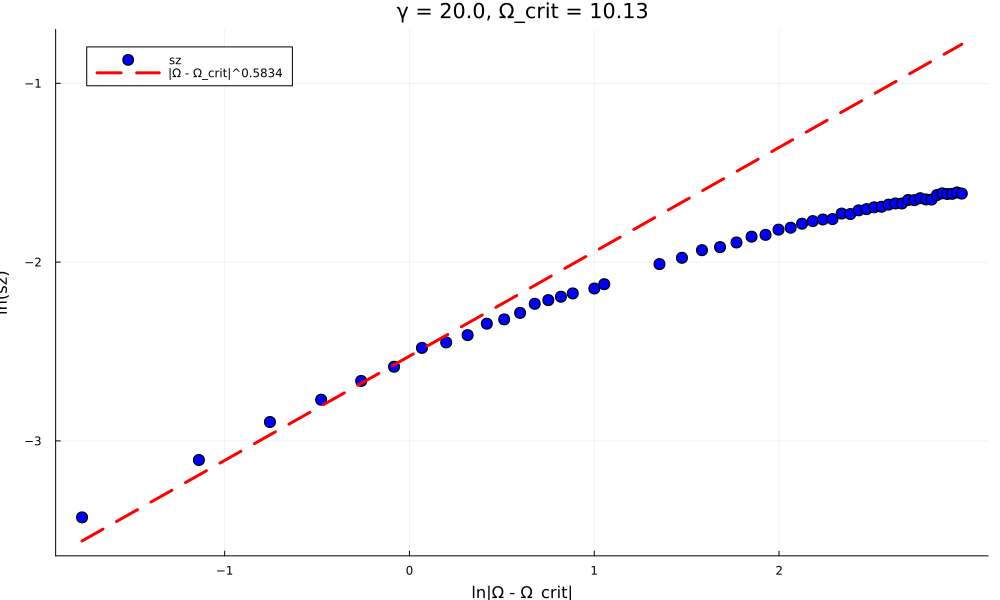

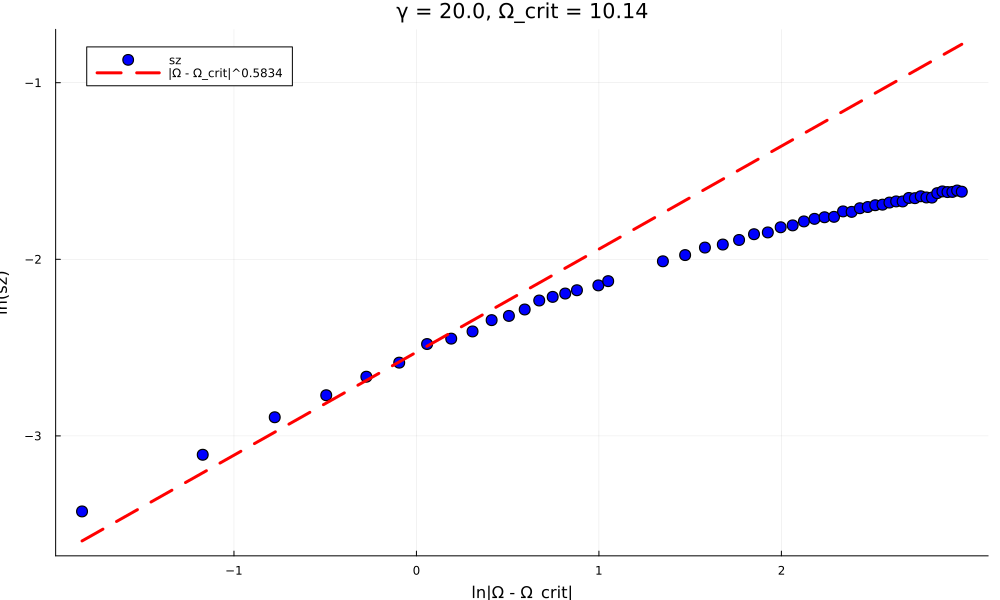

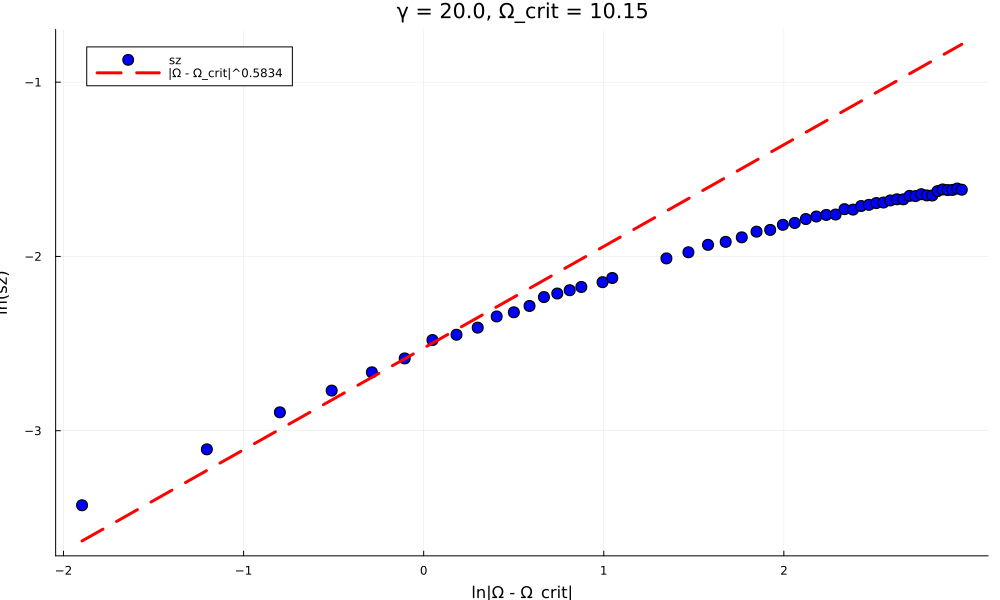

In [46]:
Ω_crit_values = 10.05:0.01:10.15
prefactor = 0.08
fixed_beta = 0.5834
for γ in γ_values
    last_Szs_mean_values = Float64[]
    valid_Ω_values = Float64[]
    for Ω in Ω_values
        if haskey(data_dict[γ], Ω)
            _, Szs_mean = data_dict[γ][Ω]
            push!(last_Szs_mean_values, Szs_mean[end])
            push!(valid_Ω_values, Ω)
        end
    end
    for Ω_crit in Ω_crit_values
        final_sz_values = Float64[]
        filtered_Ω_values = Float64[]
        for (i, Ω) in enumerate(valid_Ω_values)
            if Ω - Ω_crit > 0.1
                push!(final_sz_values, last_Szs_mean_values[i])
                push!(filtered_Ω_values, Ω)
            end
        end
        if !isempty(filtered_Ω_values)
            valid_indices = (final_sz_values .> 0) .& (abs.(filtered_Ω_values .- Ω_crit) .> 0)
            if any(valid_indices)
                yaxis_temp = log.(final_sz_values[valid_indices])
                valid_y_indices = yaxis_temp .>= -4
                if any(valid_y_indices)
                    xaxis = log.(abs.(filtered_Ω_values[valid_indices][valid_y_indices] .- Ω_crit))
                    yaxis = yaxis_temp[valid_y_indices]
                    plt3 = scatter(
                        xaxis,
                        yaxis,
                        xlabel="ln|Ω - Ω_crit|",
                        ylabel="ln(sz)",
                        marker=:circle,
                        markersize=6,
                        color=:blue,
                        legend=:topleft,
                        label="sz",
                        title="γ = $γ, Ω_crit = $Ω_crit",
                        size=(1000, 600),
                        xticks=[-2, -1, 0, 1, 2],
                        yticks=[-3, -2, -1, 0]
                    )
                    power_law_y = log.(abs.(filtered_Ω_values[valid_indices][valid_y_indices] .- Ω_crit) .^ fixed_beta .* prefactor)
                    plot!(
                        plt3,
                        xaxis,
                        power_law_y,
                        color=:red,
                        linestyle=:dash,
                        label="|Ω - Ω_crit|^$(fixed_beta)",
                        linewidth=3
                    )
                    display(plt3)
                else
                    println("All ln(sz) values < -3 for γ = $γ, Ω_crit = $Ω_crit")
                end
            else
                println("No valid positive values for γ = $γ, Ω_crit = $Ω_crit")
            end
        end
    end
end
plt1 = nothing
plt2 = nothing
GC.gc()